# Final ML Evaluation & Dataset Validation

## Inputs

- `data/processed/cicids2017/train.parquet`
- `data/processed/cicids2017/validation.parquet`
- `data/processed/cicids2017/test.parquet`
- `data/processed/cicids2017/feature_columns.json`
- `data/processed/cicids2017/label_mapping.json`
- `results/ml_baseline/selected_baseline.json`

In [1]:
from pathlib import Path
import json, time, gc
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

REPO=Path("/content/drive/MyDrive/CIC-Dataset-Analysis")
DATA_DIR=REPO/"data/processed/cicids2017"
BASELINE_DIR=REPO/"results/ml_baseline"
OUT_DIR=REPO/"results/ml_final_evaluation"
OUT_DIR.mkdir(parents=True,exist_ok=True)

with open(DATA_DIR/"feature_columns.json") as f:
    features=json.load(f)
with open(DATA_DIR/"label_mapping.json") as f:
    label_mapping=json.load(f)
with open(BASELINE_DIR/"selected_baseline.json") as f:
    selected=json.load(f)

model=joblib.load(BASELINE_DIR/f"{selected['model']}.joblib")
test=pd.read_parquet(DATA_DIR/"test.parquet")
X_test=test[features]
y_test=test["label"]

print("Model:",selected["model"])
print("Test shape:",test.shape)

Mounted at /content/drive
Model: RandomForest
Test shape: (424612, 79)


## 1. Integrity checks

Before evaluating, verify:

- feature ordering matches the saved specification
- target is not present in the feature list
- no NaN or infinite values remain
- test labels are known
- no train/test row identifiers are accidentally carried into the model matrix

In [2]:
assert "label" not in features
assert X_test.columns.tolist()==features
assert np.isfinite(X_test.to_numpy()).all(), "Non-finite values remain in test features."
assert X_test.isna().sum().sum()==0, "NaNs remain in test features."

known_ids=set(label_mapping.values())
unknown=set(y_test.unique())-known_ids
assert not unknown, f"Unknown test label IDs: {unknown}"

print("Integrity checks passed.")

Integrity checks passed.


## 2. Final held-out test evaluation

In [3]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, classification_report, confusion_matrix
)

start=time.perf_counter()
test_pred=model.predict(X_test)
inference_seconds=time.perf_counter()-start

metrics={
    "model":selected["model"],
    "accuracy":accuracy_score(y_test,test_pred),
    "balanced_accuracy":balanced_accuracy_score(y_test,test_pred),
    "macro_precision":precision_score(y_test,test_pred,average="macro",zero_division=0),
    "macro_recall":recall_score(y_test,test_pred,average="macro",zero_division=0),
    "macro_f1":f1_score(y_test,test_pred,average="macro",zero_division=0),
    "weighted_f1":f1_score(y_test,test_pred,average="weighted",zero_division=0),
    "inference_seconds":inference_seconds,
    "test_rows":len(test)
}

model_path = BASELINE_DIR / f"{selected['model']}.joblib"
metrics["model_size_bytes"] = model_path.stat().st_size
final_metrics = pd.DataFrame([metrics])
final_metrics.to_csv(OUT_DIR/"final_test_metrics.csv", index=False)
display(final_metrics)


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,inference_seconds,test_rows,model_size_bytes
0,RandomForest,0.998297,0.827005,0.870458,0.827005,0.843981,0.998264,4.877658,424612,62959553


## 3. Per-class final results

In [4]:
report=classification_report(
    y_test,test_pred,output_dict=True,zero_division=0
)

rows=[]
for cls,vals in report.items():
    if str(cls).isdigit():
        rows.append({
            "label_id":int(cls),
            "precision":vals["precision"],
            "recall":vals["recall"],
            "f1":vals["f1-score"],
            "support":vals["support"]
        })

per_class=pd.DataFrame(rows).sort_values("f1")
display(per_class)
per_class.to_csv(OUT_DIR/"final_per_class_metrics.csv",index=False)

,label_id,precision,recall,f1,support
13,13,0.000000,0.000000,0.000000,3.0
14,14,0.476923,0.316327,0.380368,98.0
9,9,1.000000,0.600000,0.750000,5.0
12,12,0.745833,0.792035,0.768240,226.0
1,1,0.862745,0.745763,0.800000,295.0
5,5,0.989091,0.989091,0.989091,825.0
10,10,0.993377,0.994044,0.993710,23840.0
11,11,1.000000,0.987571,0.993746,885.0
6,6,0.995386,0.993096,0.994240,869.0
3,3,0.996753,0.994171,0.995460,1544.0


## 4. Final confusion matrix

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
true_label,,,,,,,,,,,,,,,
0,340703,35,0,2,63,5,1,0,0,0,156,0,0,0,0
1,75,220,0,0,0,0,0,0,0,0,0,0,0,0,0
2,17,0,19186,0,1,0,0,0,0,0,0,0,0,0,0
3,5,0,0,1535,3,1,0,0,0,0,0,0,0,0,0
4,61,0,2,3,34593,0,0,0,0,0,2,0,0,0,0
5,5,0,0,0,0,816,3,0,0,0,0,0,1,0,0
6,2,0,0,0,1,3,863,0,0,0,0,0,0,0,0
7,3,0,0,0,0,0,0,1187,0,0,0,0,0,0,1
8,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


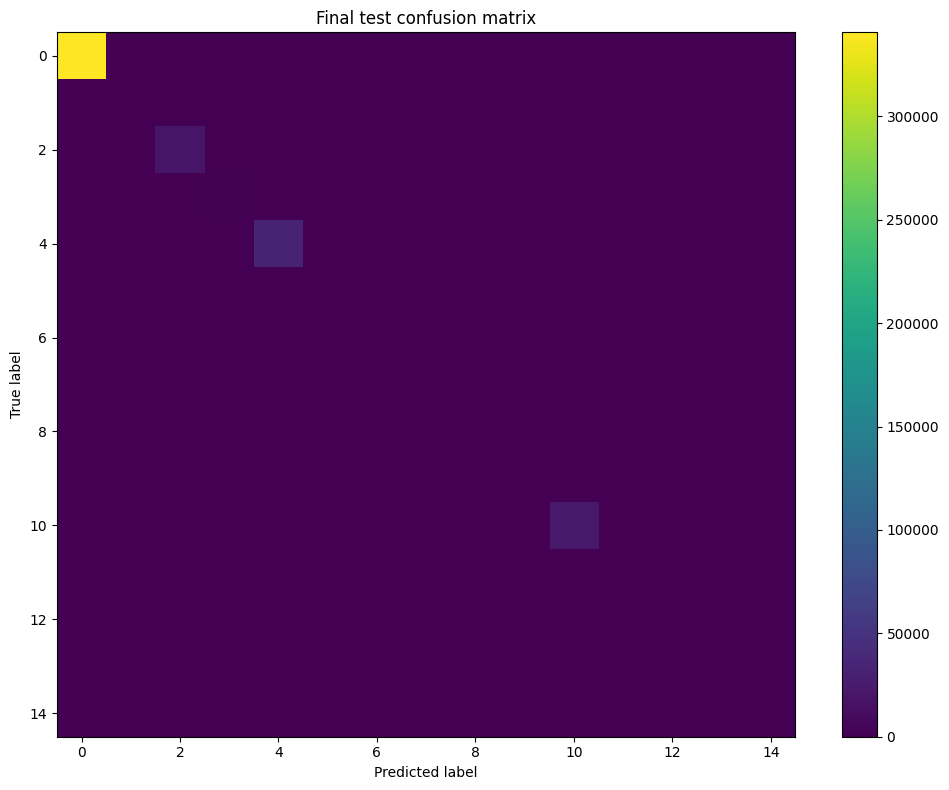

In [5]:
labels=sorted(label_mapping.values())
cm=confusion_matrix(y_test,test_pred,labels=labels)
cm_df=pd.DataFrame(cm,index=labels,columns=labels)
cm_df.index.name="true_label"
cm_df.to_csv(OUT_DIR/"final_confusion_matrix.csv")
display(cm_df)

plt.figure(figsize=(10,8))
plt.imshow(cm,aspect="auto")
plt.title("Final test confusion matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.colorbar()
plt.tight_layout()
plt.show()

## 5. Minority-class failure analysis

Flag classes with low recall and/or low support. These are not automatically removed from the problem; they are reported as limitations of the benchmark.

In [6]:
support=per_class["support"]
analysis=per_class.copy()
analysis["support_bucket"]=pd.cut(
    analysis["support"],
    bins=[-1,100,1000,10000,float("inf")],
    labels=["very_low","low","moderate","high"]
)
analysis["needs_attention"]=(analysis["recall"]<0.50) | (analysis["f1"]<0.50)
display(analysis.sort_values(["needs_attention","recall"],ascending=[False,True]))
analysis.to_csv(OUT_DIR/"minority_class_analysis.csv",index=False)

,label_id,precision,recall,f1,support,support_bucket,needs_attention
13,13,0.000000,0.000000,0.000000,3.0,very_low,True
14,14,0.476923,0.316327,0.380368,98.0,very_low,True
9,9,1.000000,0.600000,0.750000,5.0,very_low,False
1,1,0.862745,0.745763,0.800000,295.0,low,False
12,12,0.745833,0.792035,0.768240,226.0,low,False
11,11,1.000000,0.987571,0.993746,885.0,low,False
5,5,0.989091,0.989091,0.989091,825.0,low,False
6,6,0.995386,0.993096,0.994240,869.0,low,False
10,10,0.993377,0.994044,0.993710,23840.0,high,False
3,3,0.996753,0.994171,0.995460,1544.0,moderate,False


## 6. Dataset-level conclusion

The final conclusion must distinguish three questions:

1. **Dataset suitability:** was CIC-IDS2017 a defensible dataset choice?
2. **Model suitability:** does the baseline provide useful multiclass detection?
3. **Deployment readiness:** is this model ready for a real IDS? Usually, a benchmark result alone is **not** enough to claim deployment readiness.

A weak result is still useful: it identifies where feature engineering, class handling, model architecture, temporal/session-aware validation or additional data are required.

In [7]:
conclusion = pd.DataFrame([
    {
        "question":"Dataset suitability",
        "assessment":"CIC-IDS2017 selected as primary dataset",
        "evidence":"Completed comparative dataset analysis"
    },
    {
        "question":"Model suitability",
        "assessment":f"{selected['model']} evaluated using macro-F1 and minority-class metrics",
        "evidence":"Final held-out test evaluation"
    },
    {
        "question":"Deployment readiness",
        "assessment":"Not established by benchmark evaluation alone",
        "evidence":"Requires operational/temporal validation and IDS integration testing"
    }
])
display(conclusion)
conclusion.to_csv(OUT_DIR/"final_conclusion_summary.csv",index=False)

,question,assessment,evidence
0,Dataset suitability,CIC-IDS2017 selected as primary dataset,Completed comparative dataset analysis
1,Model suitability,RandomForest evaluated using macro-F1 and mino...,Final held-out test evaluation
2,Deployment readiness,Not established by benchmark evaluation alone,Requires operational/temporal validation and I...


## Conclusion

The selected model has now been evaluated against the held-out CIC-IDS2017 test set.

The final project conclusion should report the actual metric values generated above, emphasize macro-F1 and minority-class recall, identify difficult attack categories, and avoid claiming real-world deployment readiness from a static benchmark alone.

This closes the notebook-based ML evaluation phase.